# Interactive Script (for development purposes only)

In [1]:
!which python

/dss/dsstbyfs02/pr94no/pr94no-dss-0001/drylands/envs/stac2cube/bin/python


## Geometry comparison between two data arrays

In [21]:
def check_geometry_match(existing, lazy):
    # Check if both datasets have 'x' and 'y' coordinates
    for coord in ['x', 'y']:
        if coord not in existing.coords or coord not in lazy.coords:
            raise ValueError(f"Missing spatial coordinate '{coord}' in one of the datasets.")
        
        # Compare coordinate values (assumes coordinates are numpy arrays or similar)
        if not np.array_equal(existing.coords[coord].values, lazy.coords[coord].values):
            raise ValueError("The provided STAC datasets are from different regions and have incompatible spatial grids.")
    return True

In [22]:
check_geometry_match(stac_existing, stac_lazy)

True

In [1]:
from stac2cube import get_stac

In [3]:
get_stac

<function stac2cube.get_data.get_stac(mission: str, polygon, resolution, daterange: list, bands: list, max_cc: int, cloud_masking: bool)>

## Tile extraction

In [6]:
!pip list

Package                   Version
------------------------- -----------
asttokens                 3.0.0
attrs                     25.3.0
certifi                   2025.1.31
charset-normalizer        3.4.1
comm                      0.2.2
debugpy                   1.8.13
decorator                 5.2.1
executing                 2.2.0
idna                      3.10
ipykernel                 6.29.5
ipython                   9.0.2
ipython_pygments_lexers   1.1.1
jedi                      0.19.2
jsonschema                4.23.0
jsonschema-specifications 2024.10.1
jupyter_client            8.6.3
jupyter_core              5.7.2
matplotlib-inline         0.1.7
nest-asyncio              1.6.0
packaging                 24.2
parso                     0.8.4
pexpect                   4.9.0
pip                       25.0.1
platformdirs              4.3.7
prompt_toolkit            3.0.50
psutil                    7.0.0
ptyprocess                0.7.0
pure_eval                 0.2.3
Pygments           

In [2]:
!python --version

Python 3.12.9


In [2]:
from pystac_client import Client as pystacclient
catalog = pystacclient.open('https://stac.terrabyte.lrz.de/public/api') #https://planetarycomputer.microsoft.com/api/stac/v1
 
# list the IDs of all STAC catalog collections
for collection in catalog.get_all_collections():
    print(collection.id)

APIError: 'utf-8' codec can't decode byte 0xbd in position 1: invalid start byte

In [3]:
from pystac_client import Client as pystacclient
catalog_url = 'https://stac.terrabyte.lrz.de/public/api/'
catalog = pystacclient.open(catalog_url)

bbox_list= [100.767417,45.208589,100.783210,45.215543]
collection = 'sentinel-2-c1-l2a'
bbox = bbox_list
start = '2020-07-20'
end = '2020-09-30'
results = catalog.search(
    bbox = bbox,
    collections=[collection],
    datetime=[start, end]
)
items = results.item_collection()
print("%s items found" % len(items))

APIError: 'utf-8' codec can't decode byte 0xbd in position 1: invalid start byte

In [2]:
items

In [3]:
sample_item = items[0]

In [5]:
sample_item

<Item id=S1B_IW_GRDH_1SDV_20200928T232444_20200928T232509_023582_02CCE7_rtc>

In [7]:
sample_item.properties["sat:orbit_state"]

'descending'

In [51]:
import geopandas as gpd
#stac_json = items
gdf = gpd.GeoDataFrame.from_features(items, "epsg:4326")

In [ ]:
gdf

In [ ]:
#gdf = gpd.GeoDataFrame.from_features(stac_json, "epsg:4326")

# Compute granule id from components
gdf["granule"] = (
    gdf["mgrs:utm_zone"].apply(lambda x: f"{x:02d}")
    + gdf["mgrs:latitude_band"]
    + gdf["mgrs:grid_square"]
)

In [ ]:
gdf["granule"]

In [47]:
unique_values = gdf["granule"].unique()
unique_values

array(['47TPL'], dtype=object)

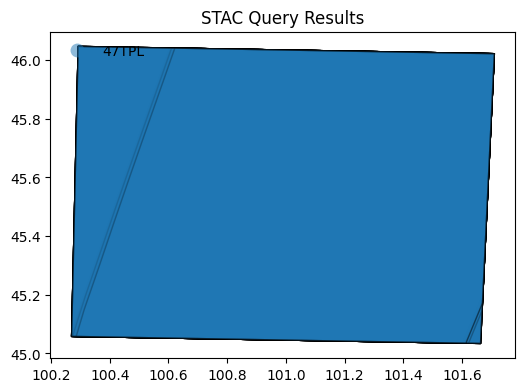

In [48]:
fig = gdf.plot(
    "granule",
    edgecolor="black",
    categorical=True,
    aspect="equal",
    alpha=0.5,
    figsize=(6, 12),
    legend=True,
    legend_kwds={"loc": "upper left", "frameon": False, "ncol": 1},
)
_ = fig.set_title("STAC Query Results")

## Native Cloud Masking

### Sentinel 2

In [1]:
from stac2cube import get_stac_layers
from stac2cube import interactive_time_view

In [2]:
mission = "s2"                              # both name and allias work. Can not be None!
polygon = "./polygons/test.gpkg"            # if not available, try optional cell below
resolution = 10                             # if None -> default_resolution
daterange = ["2024-04-01", "2024-04-30"]    # if None -> every available date
bands = ["blue", "green", "red", "nir",]    # if None -> all bands of the relevant mission, but also SCL
max_cc = 100                                # 0-100, if None -> 100
clip_raster = False                         # if None -> False
cloud_masking = True                       # if None -> False
indices = ["ndvi", "ndwi"]                  # if None -> no indices
output = None                               # Will return lazy! To export, replace with path to netcdf.
stats = None                                # if None -> no stats
aggregator = None                           # if None -> no aggregation
animation = False                           # if None -> no animation

In [3]:
stac = get_stac_layers(mission=mission, polygon=polygon, resolution=resolution, 
                            daterange=daterange, bands=bands, max_cc=max_cc, 
                            clip_raster=clip_raster, cloud_masking=cloud_masking, indices=indices, 
                            output=output, aggregator=aggregator, stats=stats,
                            animation=animation)

<xarray.DataArray 'Spectral_Temporal_Stack' (time: 12, band: 6, y: 247, x: 511)> Size: 36MB
dask.array<transpose, shape=(12, 6, 247, 511), dtype=float32, chunksize=(1, 1, 247, 511), chunktype=numpy.ndarray>
Coordinates:
  * y            (y) float64 2kB 4.547e+06 4.547e+06 ... 4.544e+06 4.544e+06
  * x            (x) float64 4kB 6.67e+05 6.67e+05 ... 6.721e+05 6.721e+05
  * band         (band) <U5 120B 'blue' 'green' 'red' 'nir' 'ndvi' 'ndwi'
  * time         (time) datetime64[ns] 96B 2024-04-01 2024-04-03 ... 2024-04-28
    spatial_ref  int64 8B 0
Attributes:
    indices:         ['ndvi', 'ndwi']
    spectral_bands:  ['blue', 'green', 'red', 'nir']
    mission:         sentinel_2_l2a
    tile_id:         ['35TPF']
    bbox:            [28.98752355404842, 41.03150270425637, 29.04759458831022...
    crs:             WGS 84 / UTM zone 35N
    transform:       | 10.00, 0.00, 667020.00|\n| 0.00,-10.00, 4546620.00|\n|...


In [4]:
interactive_time_view(stac=stac, display_mode='rgb', widget_type='slider')

interactive(children=(IntSlider(value=0, description='Time', layout=Layout(width='800px'), max=11), Output()),…

In [5]:
interactive_time_view(stac=stac, display_mode='rgb', widget_type='slider')

interactive(children=(IntSlider(value=0, description='Time', layout=Layout(width='800px'), max=11), Output()),…

In [16]:
from timeit import timeit

In [17]:
iteration= 10

t = timeit(lambda: get_stac_layers(
    mission=mission,
    polygon=polygon,
    resolution=resolution,
    daterange=daterange,
    bands=bands,
    max_cc=max_cc,
    clip_raster=clip_raster,
    cloud_masking=cloud_masking,
    indices=indices,
    output=output,
    aggregator=aggregator,
    stats=stats,
    animation=animation
), number=iteration)

print("Total time for 10 runs:", t)
print("Average time per run:", t/iteration)

<xarray.DataArray 'Spectral_Temporal_Stack' (time: 37, band: 6, y: 247, x: 511)> Size: 112MB
dask.array<transpose, shape=(37, 6, 247, 511), dtype=float32, chunksize=(1, 1, 247, 511), chunktype=numpy.ndarray>
Coordinates:
  * y            (y) float64 2kB 4.547e+06 4.547e+06 ... 4.544e+06 4.544e+06
  * x            (x) float64 4kB 6.67e+05 6.67e+05 ... 6.721e+05 6.721e+05
  * band         (band) <U5 120B 'blue' 'green' 'red' 'nir' 'ndvi' 'ndwi'
  * time         (time) datetime64[ns] 296B 2024-04-01 2024-04-03 ... 2024-06-30
    spatial_ref  int64 8B 0
Attributes:
    indices:         ['ndvi', 'ndwi']
    spectral_bands:  ['blue', 'green', 'red', 'nir']
    mission:         sentinel_2_l2a
    tile_id:         ['35TPF']
    bbox:            [28.98752355404842, 41.03150270425637, 29.04759458831022...
    crs:             WGS 84 / UTM zone 35N
    transform:       | 10.00, 0.00, 667020.00|\n| 0.00,-10.00, 4546620.00|\n|...
<xarray.DataArray 'Spectral_Temporal_Stack' (time: 37, band: 6, y: 24